# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [1]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

datasets.disable_caching()

In [2]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_or_par_froz_text'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    True_3: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 200868
    })
    False_3: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 189741
    })
    True_4: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 199061
    })
    True_5: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 168812
    })
    False_5: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 180000
    })
    True_6: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 169067
    })
    True_7: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 142004
    })
    False_7: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
       

In [3]:
np.sum([len(d) for d in ds.values()])

np.int64(4965833)

In [4]:
ds.cleanup_cache_files()

{'True_3': 0,
 'False_3': 0,
 'True_4': 0,
 'True_5': 0,
 'False_5': 0,
 'True_6': 0,
 'True_7': 0,
 'False_7': 0,
 'True_8': 0,
 'True_9': 0,
 'False_9': 0,
 'True_10': 0,
 'True_11': 0,
 'False_11': 0,
 'True_12': 0,
 'True_13': 0,
 'False_13': 0,
 'True_14': 0,
 'True_15': 0,
 'False_15': 0,
 'True_16': 0,
 'True_17': 0,
 'False_17': 0,
 'True_18': 0,
 'True_19': 0,
 'False_19': 0,
 'True_20': 0,
 'True_21': 0,
 'False_21': 0,
 'True_22': 0,
 'True_23': 0,
 'False_23': 0,
 'True_24': 0,
 'True_25': 0,
 'False_25': 0,
 'True_26': 0,
 'True_27': 0,
 'False_27': 0,
 'True_28': 0,
 'True_29': 0,
 'False_29': 0,
 'True_30': 0,
 'True_31': 0,
 'False_31': 0,
 'True_32': 0,
 'True_33': 0,
 'False_33': 0,
 'True_34': 0,
 'True_35': 0,
 'False_35': 0,
 'True_36': 0,
 'True_37': 0,
 'False_37': 0,
 'True_38': 0,
 'True_39': 0,
 'False_39': 0,
 'True_40': 0,
 'True_41': 0,
 'False_41': 0,
 'True_42': 0,
 'True_43': 0,
 'False_43': 0,
 'True_44': 0,
 'True_45': 0,
 'False_45': 0,
 'True_46': 0,

Text(0, 0.5, 'number of examples')

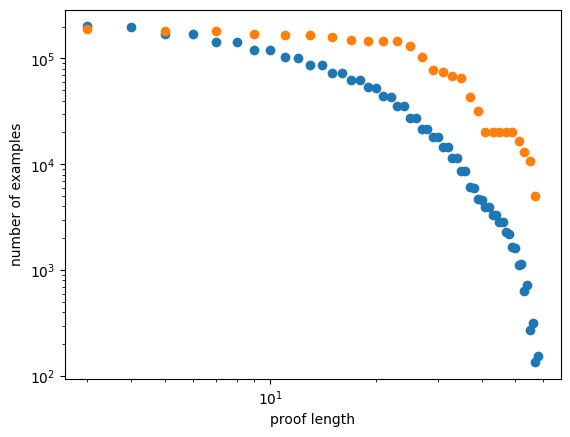

In [5]:
t_vals = []
f_vals = []
a_vals = {}

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
    
    if int(num) not in a_vals:
        a_vals[int(num)] = len(v)
    else:
        a_vals[int(num)] += len(v)
        

a_vals = list(a_vals.items())

# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
a_idx, a_lens = np.array(a_vals).T

plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

In [6]:
print(f_idx)
print(f_lens)

[ 3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47 49
 51 53 55 57]
[189741 180000 180000 171144 165000 165000 159165 150353 145000 145000
 144772 131243 103245  77398  75000  67500  65954  43671  32188  20000
  20000  20000  20000  20000  16591  12979  10679   5000]


prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     4      5      5
 0.4:     7     11     10
 0.5:     9     15     12
 0.6:    11     19     15
 0.8:    18     25     24
 0.9:    24     33     30
0.95:    30     39     36


Text(0, 0.5, 'cumulative proportion of examples')

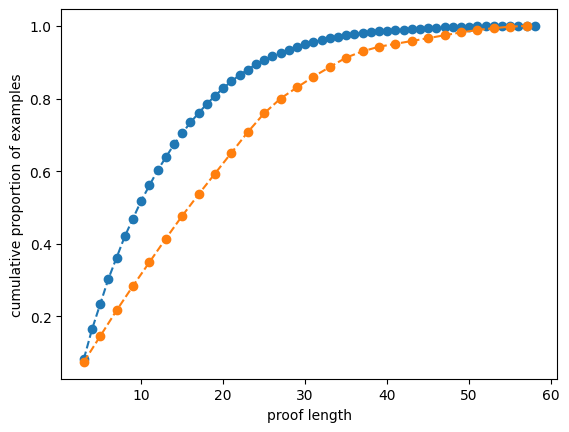

In [7]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

a_sort_idx = np.argsort(a_idx)
a_cum = np.cumsum(a_lens[a_sort_idx]) / np.sum(a_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.95]

t_idxs = []
f_idxs = []
a_idxs = []

for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())
    
    idx = np.sum(a_cum < p) - 1
    a_idxs.append(a_idx[a_sort_idx][idx].item())

print(f'prop | t_idx | f_idx | a_idx')
print('------------------------------')
for prop, t, f, a in zip(props, t_idxs, f_idxs, a_idxs):
    print(f'{prop:4}: {t:5} {f:6} {a:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [8]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=24)

Map (num_proc=24):   0%|          | 0/200868 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/189741 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/199061 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/168812 [00:00<?, ? examples/s]

Map (num_proc=24):   0%|          | 0/180000 [00:00<?, ? examples/s]

...

Token indices sequence length is longer than the specified maximum sequence length for this model (33471 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33370 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33580 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33281 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33231 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum seq

Map (num_proc=24):   0%|          | 0/5000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (34286 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (34325 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (34432 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (34675 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (36244 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum seq

Map (num_proc=24):   0%|          | 0/155 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (33134 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33892 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (34668 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (32902 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (33576 > 32768). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum seq

In [9]:
def slice_dataset(ds, start, stop):
    all_ds = []

    for key in ds.keys():
        name, i = key.split('_')
        i = int(i)

        if start <= i < stop:
            all_ds.append(ds[key].remove_columns('ops'))

    if len(all_ds) == 0:
        return ds[key].select(range(0))  # empty dataset

    return datasets.concatenate_datasets(all_ds)

train_ds = slice_dataset(ds, 0, 13)
test_ds = slice_dataset(ds, 13, np.inf)

In [10]:
def get_len(ex):
    return ex['tok_len']

with Pool(24) as pool:
    train_lens = pool.map(get_len, train_ds)
    test_lens = pool.map(get_len, test_ds)

array([ 545., 1062., 1889., 2505., 2901., 3088., 6260.])

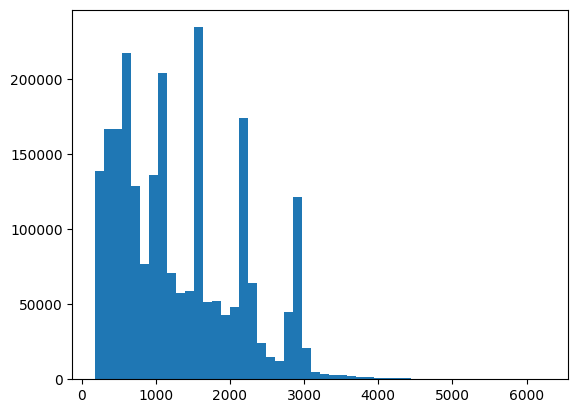

In [11]:
plt.hist(train_lens, bins=50)
np.quantile(train_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

array([ 4514.,  7094., 10987., 17049., 22261., 31166., 41062.])

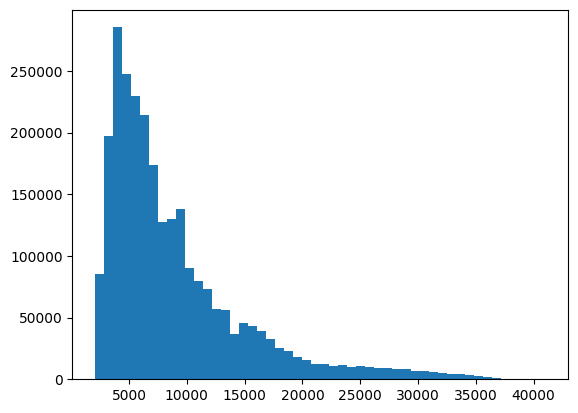

In [12]:
plt.hist(test_lens, bins=50)
np.quantile(test_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

In [21]:
test_lens = np.array(test_lens)
np.mean(test_lens < 32_768)

np.float64(0.9940936193433967)

In [18]:
train_lens = np.array(train_lens)
np.mean(train_lens < 8192)

np.float64(1.0)

In [22]:
(np.sum(train_lens) + np.sum(test_lens)) / 1e9

np.float64(26.389288193)

## Length distributions for different datasets

Full
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13
```


Imply
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2     11      3
 0.4:     3     14      5
 0.5:     3     17      9
 0.6:     3     20     12
 0.8:     5     28     21
 0.9:     8     41     29
0.95:    12     56     42
```


Or
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     3     13      3
 0.4:     5     13      5
 0.5:     6     13      6
 0.6:     7     13      7
 0.8:    10     13     10
 0.9:    12     13     13
0.95:    13     13     14
```

PHP
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    15     55     58
 0.4:    36     55     58
 0.5:    42     71     58
 0.6:    42     71     84
 0.8:    80     92     92
 0.9:    82    100     92
0.95:   143    104    110
```

### Length quantiles

TODO: can shorten context length during training for these two

Full:

3630455 points, 1.4 billion tokens

max train length < 512
max test length <~ 2048

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99]
[ 189.,  370.,  537.,  688.,  783., 1144.]
```



Implies:
11015905 points, 11.6 billion tokens

max train length < 1024
max test length <~ 16,384

```
[ 0.25,   0.5,  0.75,   0.9,  0.95,  0.99, max]
[ 275.,  634., 1126., 2117., 3125., 7494., 94357]
```